## understanding data:

In [4]:
# ======================================
# 🔁 Restore EyePACS Dataset (Double ZIP)
# ======================================

import os, zipfile


# ✅ Folder in Drive where your zips are stored
drive_folder = "/content/drive/MyDrive"   # <- change if they are in a subfolder

# ✅ Local paths in Colab
temp_dir = "/content/temp_zips"
merged_zip = "/content/train_full.zip"
extract_dir = "/content/eyepac_images"

os.makedirs(temp_dir, exist_ok=True)
os.makedirs(extract_dir, exist_ok=True)

# ======================================
# 1️⃣ First unzip: extract train.zip.001.zip ... train.zip.005.zip
# ======================================
for i in range(1, 6):
    zip_path = os.path.join(drive_folder, f"train.zip.00{i}.zip")
    print(f"🔹 Unzipping outer layer: {zip_path}")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(temp_dir)

print("✅ Outer zip extraction done.")

# ======================================
# 2️⃣ Merge all unzipped inner parts (train.zip.001 ... train.zip.005)
# ======================================
with open(merged_zip, 'wb') as wfd:
    for i in range(1, 6):
        inner_part = os.path.join(temp_dir, f"train.zip.00{i}")
        print(f"📦 Merging: {inner_part}")
        with open(inner_part, 'rb') as fd:
            wfd.write(fd.read())

print("✅ All parts merged into train_full.zip")

# ======================================
# 3️⃣ Final unzip: extract images into /content/eyepac_images/
# ======================================
print("📂 Extracting final EyePACS image dataset...")
with zipfile.ZipFile(merged_zip, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print("✅ Extraction complete! Images saved to:", extract_dir)

# ======================================
# 4️⃣ Unzip labels CSV (trainLabels.csv.zip)
# ======================================
labels_zip = os.path.join(drive_folder, "trainLabels.csv.zip")

print("🧾 Unzipping trainLabels.csv.zip ...")
with zipfile.ZipFile(labels_zip, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

# ✅ Rename CSV for convenience
os.rename(os.path.join(extract_dir, "trainLabels.csv"), os.path.join(extract_dir, "eyepac.csv"))

print("✅ Labels extracted and saved as eyepac.csv inside eyepac_images folder")

# ======================================
# 5️⃣ Verify
# ======================================
import pandas as pd
import glob

csv_path = os.path.join(extract_dir, "eyepac.csv")
df = pd.read_csv(csv_path)
img_files = glob.glob(os.path.join(extract_dir, "*.jpeg"))

print(f"\n🧠 Dataset ready!")
print(f"📁 Image folder: {extract_dir}")
print(f"🧾 CSV path: {csv_path}")
print(f"🖼️ Total images found: {len(img_files)}")
print(f"📄 CSV shape: {df.shape}")


🔹 Unzipping outer layer: /content/drive/MyDrive/train.zip.001.zip
🔹 Unzipping outer layer: /content/drive/MyDrive/train.zip.002.zip
🔹 Unzipping outer layer: /content/drive/MyDrive/train.zip.003.zip
🔹 Unzipping outer layer: /content/drive/MyDrive/train.zip.004.zip
🔹 Unzipping outer layer: /content/drive/MyDrive/train.zip.005.zip
✅ Outer zip extraction done.
📦 Merging: /content/temp_zips/train.zip.001
📦 Merging: /content/temp_zips/train.zip.002
📦 Merging: /content/temp_zips/train.zip.003
📦 Merging: /content/temp_zips/train.zip.004
📦 Merging: /content/temp_zips/train.zip.005
✅ All parts merged into train_full.zip
📂 Extracting final EyePACS image dataset...
✅ Extraction complete! Images saved to: /content/eyepac_images
🧾 Unzipping trainLabels.csv.zip ...
✅ Labels extracted and saved as eyepac.csv inside eyepac_images folder

🧠 Dataset ready!
📁 Image folder: /content/eyepac_images
🧾 CSV path: /content/eyepac_images/eyepac.csv
🖼️ Total images found: 0
📄 CSV shape: (35126, 2)


In [5]:
# Cell 1 - Setup, imports and paths
import os
from pathlib import Path
import random
import numpy as np
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
from PIL import Image, UnidentifiedImageError
from tqdm.auto import tqdm
import hashlib

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# candidate base dirs (falls back to relative)
CANDIDATES = [Path('/content/eyepac_images'), Path('eyepac_images'), Path('/mnt/data/eyepac_images')]
BASE_DIR = next((p for p in CANDIDATES if p.exists()), None)
if BASE_DIR is None:
    raise FileNotFoundError(f"Could not find eyepac_images folder. Checked: {CANDIDATES}")
print("BASE_DIR:", BASE_DIR)
# Cell 2 - List subdirectories and counts (quick inventory)
def inventory_images(base_dir: Path, exts=('.png','.jpg','.jpeg','.tif','.tiff','.bmp')):
    subdirs = [d for d in base_dir.iterdir() if d.is_dir()]
    files_in_root = [p for p in base_dir.iterdir() if p.is_file() and p.suffix.lower() in exts]
    print(f"Subdirectories found: {len(subdirs)}")
    for d in sorted(subdirs):
        count = sum(1 for p in d.rglob('*') if p.is_file() and p.suffix.lower() in exts)
        print(f"  {d.name:20s} -> {count:6d}")
    print(f"Files directly under {base_dir.name}: {len(files_in_root)}")
    return subdirs, files_in_root

subdirs, files_in_root = inventory_images(BASE_DIR)


BASE_DIR: /content/eyepac_images
Subdirectories found: 1
  train                ->  35126
Files directly under eyepac_images: 0


In [6]:
# Cell 3 - Load CSV if present and preview; detect common names
CSV_CANDIDATES = list(BASE_DIR.glob('**/*.csv')) + [Path('/content/eyepac.csv'), Path('eyepac.csv')]
csv_path = None
for c in CSV_CANDIDATES:
    if c.exists():
        csv_path = c
        break

if csv_path is None:
    print("No CSV found automatically. If you have a labels CSV, upload it or place it in the eyepac_images folder and re-run.")
    df = pd.DataFrame()
else:
    print("Using CSV:", csv_path)
    df = pd.read_csv(csv_path)
    print("CSV shape:", df.shape)
    display(df.head())
    print("Columns:", df.columns.tolist())


Using CSV: /content/eyepac_images/eyepac.csv
CSV shape: (35126, 2)


,image,level
0,10_left,0
1,10_right,0
2,13_left,0
3,13_right,0
4,15_left,1


Columns: ['image', 'level']


In [7]:
# Cell 4 - Build file map from images folder (basename -> full paths)
# This helps resolve CSV entries with/without extensions and nested folders.
def build_file_map(base_dir: Path, exts=('.png','.jpg','.jpeg','.tif','.tiff','.bmp')):
    file_map = {}
    for p in base_dir.rglob('*'):
        if p.is_file() and p.suffix.lower() in exts:
            key = p.name
            file_map.setdefault(key.lower(), []).append(p)
            # also add basename without extension
            file_map.setdefault(p.stem.lower(), []).append(p)
    return file_map

file_map = build_file_map(BASE_DIR)
print(f"Total distinct basenames in file map: {len(file_map)}")
# show some examples
sample_keys = list(file_map.keys())[:10]
for k in sample_keys:
    print(k, "->", file_map[k][:3])


Total distinct basenames in file map: 70252
23244_right.jpeg -> [PosixPath('/content/eyepac_images/train/23244_right.jpeg')]
23244_right -> [PosixPath('/content/eyepac_images/train/23244_right.jpeg')]
42909_left.jpeg -> [PosixPath('/content/eyepac_images/train/42909_left.jpeg')]
42909_left -> [PosixPath('/content/eyepac_images/train/42909_left.jpeg')]
24387_left.jpeg -> [PosixPath('/content/eyepac_images/train/24387_left.jpeg')]
24387_left -> [PosixPath('/content/eyepac_images/train/24387_left.jpeg')]
36900_right.jpeg -> [PosixPath('/content/eyepac_images/train/36900_right.jpeg')]
36900_right -> [PosixPath('/content/eyepac_images/train/36900_right.jpeg')]
14947_right.jpeg -> [PosixPath('/content/eyepac_images/train/14947_right.jpeg')]
14947_right -> [PosixPath('/content/eyepac_images/train/14947_right.jpeg')]


In [8]:
# Cell 5 - If CSV present: resolve csv filenames to actual paths; else construct dataframe from files
def resolve_csv_paths(df, file_map, fname_cols=None, label_cols=None):
    # try to detect filename column
    if fname_cols is None:
        candidates = [c for c in df.columns if 'file' in c.lower() or 'image' in c.lower() or 'fname' in c.lower() or 'name' in c.lower()]
        fname_col = candidates[0] if candidates else df.columns[0]
    else:
        fname_col = fname_cols[0]
    # try detect label column
    if label_cols is None:
        label_candidates = [c for c in df.columns if c.lower() in ('label','diagnosis','diagnose','level','level_of','dr','retinopathy','class','rating')]
        label_col = label_candidates[0] if label_candidates else df.columns[-1]
    else:
        label_col = label_cols[0]

    print("Detected filename column:", fname_col)
    print("Detected label column:", label_col)

    rows = []
    unresolved = []
    for _, r in tqdm(df.iterrows(), total=len(df)):
        raw = str(r[fname_col]).strip()
        key = raw.lower()
        resolved = file_map.get(key) or file_map.get(Path(raw).name.lower()) or file_map.get(Path(raw).stem.lower())
        if resolved:
            # choose first if multiple (prefer full path match)
            chosen = resolved[0]
            rows.append({'filepath': str(chosen), 'filename': chosen.name, 'label': r[label_col]})
        else:
            unresolved.append(raw)
    print(f"Resolved: {len(rows)} rows, Unresolved: {len(unresolved)}")
    sample_unresolved = unresolved[:10]
    if sample_unresolved:
        print("Sample unresolved entries:", sample_unresolved)
    resolved_df = pd.DataFrame(rows)
    return resolved_df, unresolved

if not df.empty:
    resolved_df, unresolved = resolve_csv_paths(df, file_map)
    # coerce label to int if possible
    try:
        resolved_df['label'] = resolved_df['label'].astype(int)
    except Exception:
        resolved_df['label'] = resolved_df['label'].astype(str)
    print("Resolved dataframe shape:", resolved_df.shape)
else:
    # Build df from files if no CSV
    rows = []
    for k, paths in file_map.items():
        for p in paths:
            rows.append({'filepath': str(p), 'filename': p.name})
    resolved_df = pd.DataFrame(rows).drop_duplicates(subset='filepath').reset_index(drop=True)
    print("Built dataframe from files:", resolved_df.shape)


Detected filename column: image
Detected label column: level


  0%|          | 0/35126 [00:00<?, ?it/s]

Resolved: 35126 rows, Unresolved: 0
Resolved dataframe shape: (35126, 3)


## Detecting Corrupted Images:

In [10]:
# Cell 6 - Corruption check (PIL verify) and compute MD5 hashes and basic image size stats
def pil_verify_and_stats(df, filepath_col='filepath', sample_limit=None):
    ok_rows = []
    bad_rows = []
    width_heights = []
    for i, row in tqdm(df.iterrows(), total=len(df) if sample_limit is None else min(len(df), sample_limit)):
        if sample_limit is not None and i >= sample_limit:
            break
        p = Path(row[filepath_col])
        try:
            with Image.open(p) as im:
                im.verify()  # verify may leave file in unusable state; reopen
            with Image.open(p) as im:
                im = im.convert('RGB')
                w, h = im.size
                width_heights.append((w,h))
            # compute small fingerprint to detect duplicates (optional)
            md5 = hashlib.md5(p.read_bytes()).hexdigest()
            ok_rows.append({**row, 'width': w, 'height': h, 'md5': md5})
        except (UnidentifiedImageError, OSError, ValueError) as e:
            bad_rows.append({'filepath': str(p), 'error': str(e)})
    ok_df = pd.DataFrame(ok_rows)
    bad_df = pd.DataFrame(bad_rows)
    return ok_df, bad_df, width_heights

ok_df, bad_df, wh = pil_verify_and_stats(resolved_df, sample_limit=None)
print("OK images:", len(ok_df), "Bad images:", len(bad_df))
if not bad_df.empty:
    display(bad_df.head())


  0%|          | 0/35126 [00:00<?, ?it/s]

OK images: 35126 Bad images: 0


In [11]:
# Safe to execute immediately after Cell 6
if not bad_df.empty:
    bad_paths = set(bad_df['filepath'].tolist())
    clean_df = ok_df[~ok_df['filepath'].isin(bad_paths)].reset_index(drop=True)
else:
    clean_df = ok_df.copy()

print("Final cleaned dataset size:", len(clean_df))

clean_csv_path = BASE_DIR / 'eyepacs_all_fixed.csv'
clean_df[['filename','filepath','label']].to_csv(clean_csv_path, index=False)
print("Cleaned CSV saved at:", clean_csv_path)


Final cleaned dataset size: 35126
Cleaned CSV saved at: /content/eyepac_images/eyepacs_all_fixed.csv


Width: min, median, mean, max -> 400 3888.0 3636.655241131925 5184
Height: min, median, mean, max -> 289 2592.0 2473.03316631555 3456


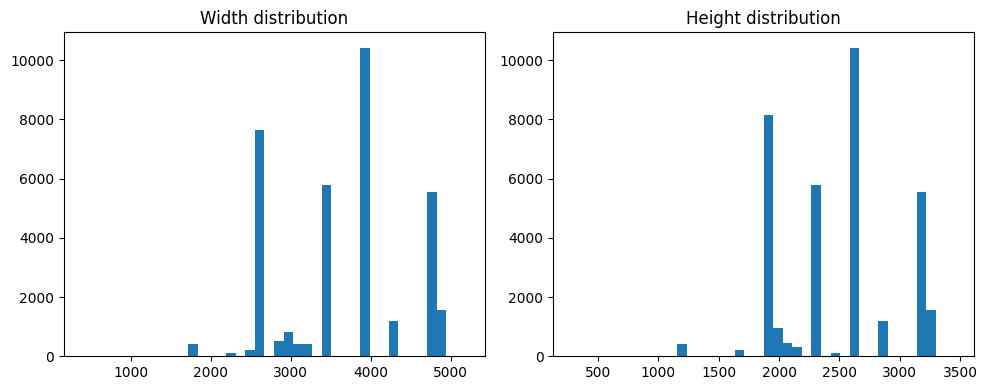

In [12]:
# Cell 7 - Image size statistics and display distribution plot
if len(wh) > 0:
    widths = [w for w,h in wh]
    heights = [h for w,h in wh]
    print("Width: min, median, mean, max ->", min(widths), np.median(widths), np.mean(widths), max(widths))
    print("Height: min, median, mean, max ->", min(heights), np.median(heights), np.mean(heights), max(heights))

    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.hist(widths, bins=40)
    plt.title('Width distribution')
    plt.subplot(1,2,2)
    plt.hist(heights, bins=40)
    plt.title('Height distribution')
    plt.tight_layout()
    plt.show()
else:
    print("No image size data available.")


Class counts:
 label
0    25810
1     2443
2     5292
3      873
4      708
Name: count, dtype: int64


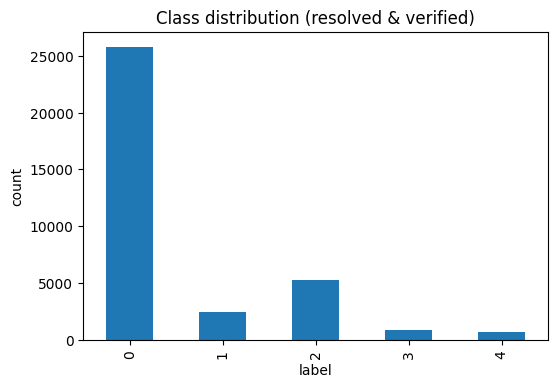

,count
label,
0,0.734783
1,0.069550
2,0.150658
3,0.024853
4,0.020156


In [13]:
# Cell 8 - If labels exist: class distribution plot and simple stats
if 'label' in ok_df.columns:
    counts = ok_df['label'].value_counts().sort_index()
    print("Class counts:\n", counts)
    plt.figure(figsize=(6,4))
    counts.plot(kind='bar')
    plt.title('Class distribution (resolved & verified)')
    plt.xlabel('label')
    plt.ylabel('count')
    plt.show()

    # fraction of dataset per class
    frac = counts / counts.sum()
    display(frac)
else:
    print("No label column in resolved dataframe. If you have labels CSV, re-run cell 3 to load it.")


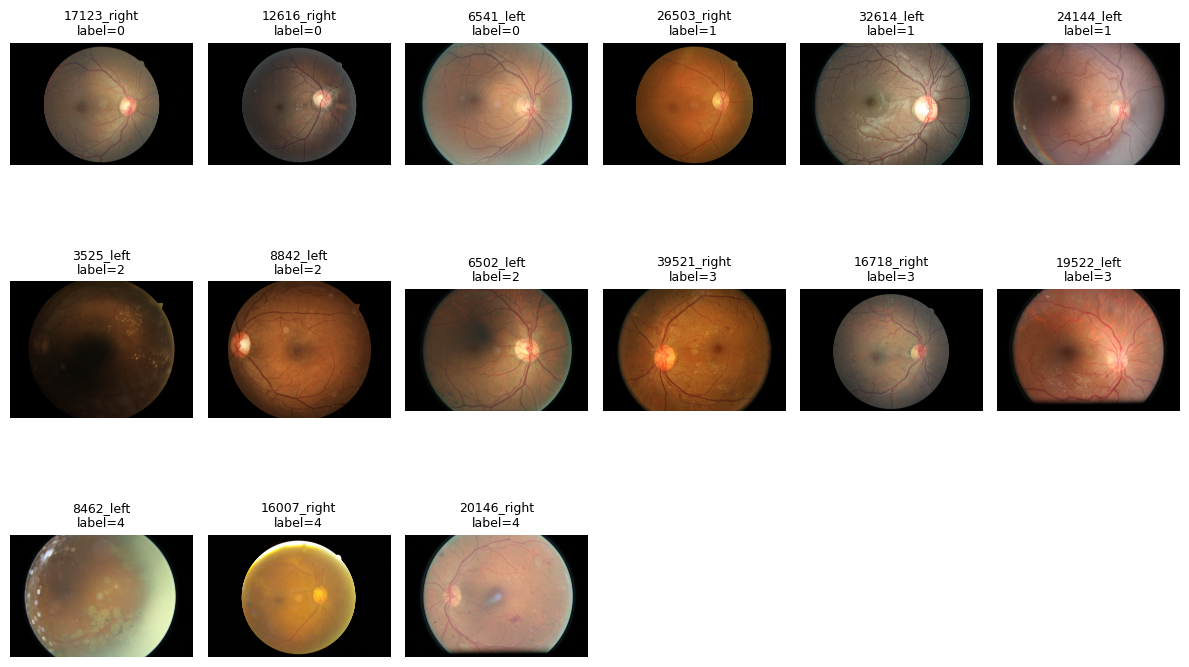

In [14]:
# Cell 9 - Show random sample grid (stratified by label if available)
def show_samples(df, n_per_class=3, figsize=(12,8)):
    if 'label' in df.columns:
        classes = sorted(df['label'].unique())
        samples = []
        for c in classes:
            subs = df[df['label'] == c]
            take = subs.sample(min(len(subs), n_per_class), random_state=SEED)
            samples.append(take)
        sample_df = pd.concat(samples).reset_index(drop=True)
    else:
        sample_df = df.sample(min(len(df), 12), random_state=SEED).reset_index(drop=True)

    n = len(sample_df)
    cols = min(6, n)
    rows = (n + cols - 1) // cols
    plt.figure(figsize=figsize)
    for i, row in sample_df.iterrows():
        try:
            img = Image.open(row['filepath']).convert('RGB')
            plt.subplot(rows, cols, i+1)
            plt.imshow(img)
            title = f"{Path(row['filename']).stem}"
            if 'label' in row:
                title += f"\nlabel={row['label']}"
            plt.title(title, fontsize=9)
            plt.axis('off')
        except Exception as e:
            plt.subplot(rows, cols, i+1)
            plt.text(0.5, 0.5, f"Error\n{e}", ha='center')
            plt.axis('off')
    plt.tight_layout()
    plt.show()

show_samples(ok_df, n_per_class=3)


In [15]:
# Cell 10 - Stratified Train/Val/Test split and save cleaned CSV
from sklearn.model_selection import train_test_split

# require label column for stratified split
if 'label' in ok_df.columns:
    df_work = ok_df.copy().reset_index(drop=True)
    # ensure integer labels if possible
    try:
        df_work['label'] = df_work['label'].astype(int)
    except Exception:
        pass

    trainval, test = train_test_split(df_work, test_size=0.10, random_state=SEED, stratify=df_work['label'])
    train, val = train_test_split(trainval, test_size=0.10, random_state=SEED, stratify=trainval['label'])  # 10% of trainval -> val

    print("Sizes -> train:", len(train), "val:", len(val), "test:", len(test))
    # save cleaned CSV
    out_csv = BASE_DIR / 'all_labels_onfly_cleaned.csv'
    df_out = pd.concat([train, val, test]).reset_index(drop=True)
    df_out[['filename','filepath','label']].to_csv(out_csv, index=False)
    print("Saved cleaned CSV to:", out_csv)
else:
    print("No label column: cannot create stratified splits. If you want simple splits, add labels first.")


Sizes -> train: 28451 val: 3162 test: 3513
Saved cleaned CSV to: /content/eyepac_images/all_labels_onfly_cleaned.csv


In [16]:
# Cell A — Setup, imports, and paths (no tensorflow-addons)
import os, random, json
from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

# Locate base folder and CSV (from your earlier EDA step)
CANDIDATES = [Path('/content/eyepac_images'), Path('eyepac_images')]
BASE_DIR = next((p for p in CANDIDATES if p.exists()), None)
if BASE_DIR is None:
    raise FileNotFoundError("Place the 'eyepac_images' folder in /content or the working directory.")

# Prefer the cleaned CSV you saved; fallback to eyepac.csv if present
CSV_CANDIDATES = [BASE_DIR/'eyepacs_all_fixed.csv', BASE_DIR/'all_labels_onfly_cleaned.csv',
                   BASE_DIR/'eyepac.csv', Path('/content/eyepac.csv')]
csv_path = next((c for c in CSV_CANDIDATES if c.exists()), None)
if csv_path is None:
    raise FileNotFoundError("No CSV found (expected eyepacs_all_fixed.csv or eyepac.csv).")

print("BASE_DIR:", BASE_DIR)
print("CSV:", csv_path)


BASE_DIR: /content/eyepac_images
CSV: /content/eyepac_images/eyepacs_all_fixed.csv


In [17]:
# Cell B — Load dataframe and ensure correct dtypes
df = pd.read_csv(csv_path)
# Expect columns: filename, filepath, label
req = {'filepath','label'}
missing = req - set(df.columns)
if missing:
    raise ValueError(f"CSV missing columns: {missing}")

# Clean + coerce
df['filepath'] = df['filepath'].astype(str)
try:
    df['label'] = df['label'].astype(int)
except:
    pass

print(df.shape)
df.head()


(35126, 3)


,filename,filepath,label
0,10_left.jpeg,/content/eyepac_images/train/10_left.jpeg,0
1,10_right.jpeg,/content/eyepac_images/train/10_right.jpeg,0
2,13_left.jpeg,/content/eyepac_images/train/13_left.jpeg,0
3,13_right.jpeg,/content/eyepac_images/train/13_right.jpeg,0
4,15_left.jpeg,/content/eyepac_images/train/15_left.jpeg,1


In [18]:
# Cell C — Stratified Train/Val/Test split (80/10/10 like the paper)
from sklearn.model_selection import train_test_split

# Stratified splits
trainval, test = train_test_split(df, test_size=0.10, random_state=SEED, stratify=df['label'])
train, val = train_test_split(trainval, test_size=0.10, random_state=SEED, stratify=trainval['label'])

for name, part in [('train',train), ('val',val), ('test',test)]:
    print(f"{name:5s} -> {len(part)}")

# Save combined split CSV (modern syntax; append() deprecated)
split_df = pd.concat([
    train.assign(split='train'),
    val.assign(split='val'),
    test.assign(split='test')
])

split_path = BASE_DIR / 'eyepacs_split.csv'
split_df.to_csv(split_path, index=False)
print("Saved split CSV ->", split_path)


train -> 28451
val   -> 3162
test  -> 3513
Saved split CSV -> /content/eyepac_images/eyepacs_split.csv


In [19]:
# Cell D — Config: image sizes and batch
# Paper uses VGG16 + InceptionV3. We'll standardize to 299x299 (bicubic),
# which suits Inception; VGG16 can also accept this when trained end-to-end.
IMG_SIZE = (299, 299)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE


In [20]:
# Cell E — Preprocessing (exactly as in paper: resize with BICUBIC + normalize)
# Ref (paper): Resizing with bicubic interpolation; normalize/standardize images. :contentReference[oaicite:1]{index=1}

def _read_image(path):
    img = tf.io.read_file(path)
    # support common formats (jpeg/png)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.convert_image_dtype(img, tf.float32)  # scales to [0,1]
    # Bicubic resize as specified
    img = tf.image.resize(img, IMG_SIZE, method=tf.image.ResizeMethod.BICUBIC, antialias=True)
    return img

@tf.function
def preprocess(path, label):
    img = _read_image(path)
    # Paper mentions normalization/standardization; we keep per-image normalization in [0,1].
    # (No extra contrast/gamma/CLAHE to stay faithful to the study.)
    return img, tf.cast(label, tf.int32)


In [21]:
# Fixed Cell F — Augmentation (flip, rotate, crop, zoom, shear) using ImageProjectiveTransformV3

rand_flip = tf.keras.layers.RandomFlip(mode="horizontal")
rand_rot  = tf.keras.layers.RandomRotation(factor=0.08)   # ~±15°
rand_zoom = tf.keras.layers.RandomZoom(height_factor=(-0.1, 0.1),
                                       width_factor=(-0.1, 0.1))
rand_crop = tf.keras.layers.RandomCrop(height=IMG_SIZE[0], width=IMG_SIZE[1])

def _build_shear_transform(sh):
    # Projective transform parameters (maps output coords to input coords)
    # We use an affine shear matrix:
    # [ 1   sh  0
    #   0   1   0
    #   0   0   1 ]
    # The transform vector expected by TF: [a, b, c, d, e, f, g, h]
    # For a simple affine with no projective terms, g=h=0.
    return tf.convert_to_tensor([1.0, sh, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0], dtype=tf.float32)

def shear_image(img, shear_deg=10.0):
    # img: float32 tensor shape (H,W,3), values in [0,1]
    shear_rad = tf.random.uniform([], -shear_deg, shear_deg) * (np.pi/180.0)
    sh = tf.tan(shear_rad)
    h = tf.shape(img)[0]
    w = tf.shape(img)[1]
    transform = _build_shear_transform(sh)               # shape (8,)
    transforms = tf.expand_dims(transform, axis=0)      # shape (1,8)
    imgs = tf.expand_dims(img, axis=0)                  # shape (1,H,W,3)
    # ImageProjectiveTransformV3 expects output_shape as [out_h, out_w]
    out = tf.raw_ops.ImageProjectiveTransformV3(
        images=imgs,
        transforms=transforms,
        output_shape=tf.convert_to_tensor([h, w], dtype=tf.int32),
        interpolation="BILINEAR",
        fill_value=0.0
    )
    out = tf.squeeze(out, axis=0)
    return out

def augment_image(img):
    # img: Tensor float32 [0,1], shape (H,W,3)
    img = rand_flip(img)
    img = rand_rot(img)
    img = rand_zoom(img)
    img = shear_image(img)
    # ensure final crop (keeps output exactly IMG_SIZE)
    img = rand_crop(img)
    return img

@tf.function
def preprocess_with_aug(path, label):
    img, label = preprocess(path, label)   # uses your existing preprocess (bicubic resize + to float32)
    img = augment_image(img)
    return img, label


In [22]:
# Cell G — Build tf.data datasets (train with augmentation; val/test without)
def make_ds(frame, training=False):
    paths = frame['filepath'].values
    labels = frame['label'].values
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(buffer_size=len(frame), seed=SEED, reshuffle_each_iteration=True)
        ds = ds.map(preprocess_with_aug, num_parallel_calls=AUTOTUNE)
    else:
        ds = ds.map(preprocess, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_ds(train, training=True)
val_ds   = make_ds(val,   training=False)
test_ds  = make_ds(test,  training=False)

train_ds, val_ds, test_ds


(<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 299, 299, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>,
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 299, 299, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>,
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 299, 299, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>)

In [2]:
# Cell J — Visualize before vs after augmentation
import matplotlib.pyplot as plt
import tensorflow as tf
import random

N = 6   # number of examples to show
samples = train.sample(N, random_state=SEED)

plt.figure(figsize=(8, 2*N))
for i, (_, row) in enumerate(samples.iterrows()):
    path, label = row['filepath'], row['label']

    # Load preprocessed (no augmentation)
    orig_img, _ = preprocess(path, label)
    orig_img = tf.image.convert_image_dtype(orig_img, tf.uint8)

    # Load augmented version
    aug_img, _ = preprocess_with_aug(path, label)
    aug_img = tf.image.convert_image_dtype(aug_img, tf.uint8)

    # Show original
    plt.subplot(N, 2, 2*i + 1)
    plt.imshow(orig_img)
    plt.title(f"Original\nLabel = {label}", fontsize=10)
    plt.axis('off')

    # Show augmented
    plt.subplot(N, 2, 2*i + 2)
    plt.imshow(aug_img)
    plt.title(f"Augmented\nLabel = {label}", fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()


NameError: name 'train' is not defined

In [25]:
# Cell M1 - Build Hybrid VGG16 + InceptionV3 model (feature concat + FC head)
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.applications import VGG16, InceptionV3

NUM_CLASSES = 5
IMG_SHAPE = (IMG_SIZE[0], IMG_SIZE[1], 3)  # expects 299x299x3 from earlier

# Load backbones (imagenet weights), without top classification head
# Paper states combining outputs of last conv layers of both networks. :contentReference[oaicite:2]{index=2}
vgg_base = VGG16(include_top=False, weights='imagenet', input_shape=IMG_SHAPE)
inc_base = InceptionV3(include_top=False, weights='imagenet', input_shape=IMG_SHAPE)

# Freeze the base models initially (paper uses transfer learning strategy)
for layer in vgg_base.layers:
    layer.trainable = False
for layer in inc_base.layers:
    layer.trainable = False

# Select the last convolutional outputs
# For VGG16 last conv is 'block5_conv3'
vgg_feat = vgg_base.get_layer('block5_conv3').output   # shape: (H, W, 512)
# For InceptionV3 we take the final mixed feature map, typically 'mixed10'
# If not present in this TF implementation, use the model's output
try:
    inc_feat = inc_base.get_layer('mixed10').output
except Exception:
    inc_feat = inc_base.output

# Apply Global Average Pooling to both (paper indicates GA pooling). :contentReference[oaicite:3]{index=3}
vgg_gap = layers.GlobalAveragePooling2D(name='vgg_gap')(vgg_feat)
inc_gap = layers.GlobalAveragePooling2D(name='inc_gap')(inc_feat)

# Optionally add small Dense->BN on each before concat (stabilizes)
vgg_proj = layers.Dense(512, activation='relu', name='vgg_proj')(vgg_gap)
inc_proj = layers.Dense(512, activation='relu', name='inc_proj')(inc_gap)

# Concatenate projected features
concat = layers.Concatenate(name='concat_feats')([vgg_proj, inc_proj])  # 1024 dims

# Fully connected head as per paper: two FC layers (4096, 4096) with dropout 0.5. :contentReference[oaicite:4]{index=4}
fc = layers.Dense(4096, activation='relu', kernel_regularizer=regularizers.l2(1e-4), name='fc1')(concat)
fc = layers.BatchNormalization()(fc)
fc = layers.Dropout(0.5)(fc)

fc = layers.Dense(4096, activation='relu', kernel_regularizer=regularizers.l2(1e-4), name='fc2')(fc)
fc = layers.BatchNormalization()(fc)
fc = layers.Dropout(0.5)(fc)

outputs = layers.Dense(NUM_CLASSES, activation='softmax', name='predictions')(fc)

# Build model (inputs: use one of the base models' inputs - ensure same input used for both)
# We must create a new Input so both bases share same input tensor
inp = layers.Input(shape=IMG_SHAPE, name='input_image')
vgg_out = vgg_base(inp)          # run vgg on the shared input
inc_out = inc_base(inp)          # run inception on the shared input

# Re-extract the feature maps from these functional outputs
vgg_feat2 = vgg_base.get_layer('block5_conv3').output
# To use functional API properly we need to reconstruct pipeline using the base models applied to inp.
# Simpler: re-create short models mapping input->selected layer outputs:
vgg_trunc = tf.keras.Model(inputs=vgg_base.input, outputs=vgg_base.get_layer('block5_conv3').output, name='vgg_trunc')
inc_trunc = tf.keras.Model(inputs=inc_base.input, outputs=(inc_base.get_layer('mixed10').output if 'mixed10' in [l.name for l in inc_base.layers] else inc_base.output), name='inc_trunc')

# Apply truncated models to shared input
vgg_x = vgg_trunc(inp)
inc_x = inc_trunc(inp)

# Now reuse pooling/proj/concat/head defined above but applied to vgg_x/inc_x:
vgg_x = layers.GlobalAveragePooling2D(name='vgg_gap')(vgg_x)
inc_x = layers.GlobalAveragePooling2D(name='inc_gap')(inc_x)
vgg_x = layers.Dense(512, activation='relu', name='vgg_proj')(vgg_x)
inc_x = layers.Dense(512, activation='relu', name='inc_proj')(inc_x)
x = layers.Concatenate(name='concat_feats')([vgg_x, inc_x])
x = layers.Dense(4096, activation='relu', kernel_regularizer=regularizers.l2(1e-4), name='fc1')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(4096, activation='relu', kernel_regularizer=regularizers.l2(1e-4), name='fc2')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
out = layers.Dense(NUM_CLASSES, activation='softmax', name='predictions')(x)

hybrid_model = tf.keras.Model(inputs=inp, outputs=out, name='VGG16_InceptionV3_Hybrid')


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [28]:
# Safe recompile & train
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import SparseCategoricalAccuracy

hybrid_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=[SparseCategoricalAccuracy(name='accuracy')]
)

# Confirm new metrics
hybrid_model.summary()

# Train
EPOCHS = 6
history = hybrid_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)


Model: "VGG16_InceptionV3_Hybrid"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg_trunc           │ (None, 18, 18,    │ 14,714,688 │ input_image[0][0] │
│ (Functional)        │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inc_trunc           │ (None, 8, 8,      │ 21,802,784 │ input_image[0][0] │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg_gap             │ (None, 512)       │          0 │ vgg_trunc[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inc_gap             │ (None, 2048)      │          0 │ inc_trunc[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg_proj (Dense)    │ (None, 512)       │    262,656 │ vgg_gap[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inc_proj (Dense)    │ (None, 512)       │  1,049,088 │ inc_gap[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_feats        │ (None, 1024)      │          0 │ vgg_proj[0][0],   │
│ (Concatenate)       │                   │            │ inc_proj[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc1 (Dense)         │ (None, 4096)      │  4,198,400 │ concat_feats[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 4096)      │     16,384 │ fc1[0][0]         │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 4096)      │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc2 (Dense)         │ (None, 4096)      │ 16,781,312 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 4096)      │     16,384 │ fc2[0][0]         │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 4096)      │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ predictions (Dense) │ (None, 5)         │     20,485 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 58,862,181 (224.54 MB)

 Trainable params: 22,328,325 (85.18 MB)

 Non-trainable params: 36,533,856 (139.37 MB)

Epoch 1/6
890/890 ━━━━━━━━━━━━━━━━━━━━ 0s 670ms/step - accuracy: 0.4138 - loss: 2.4689
Epoch 1: val_accuracy improved from -inf to 0.73276, saving model to /content/eyepac_images/hybrid_best.h5


890/890 ━━━━━━━━━━━━━━━━━━━━ 694s 759ms/step - accuracy: 0.4139 - loss: 2.4685 - val_accuracy: 0.7328 - val_loss: 1.5291 - learning_rate: 1.0000e-04
Epoch 2/6
889/890 ━━━━━━━━━━━━━━━━━━━━ 0s 653ms/step - accuracy: 0.6501 - loss: 1.6314
Epoch 2: val_accuracy did not improve from 0.73276
890/890 ━━━━━━━━━━━━━━━━━━━━ 636s 715ms/step - accuracy: 0.6501 - loss: 1.6313 - val_accuracy: 0.6841 - val_loss: 1.2604 - learning_rate: 1.0000e-04
Epoch 3/6
889/890 ━━━━━━━━━━━━━━━━━━━━ 0s 653ms/step - accuracy: 0.6832 - loss: 1.4359
Epoch 3: val_accuracy improved from 0.73276 to 0.73624, saving model to /content/eyepac_images/hybrid_best.h5


890/890 ━━━━━━━━━━━━━━━━━━━━ 637s 716ms/step - accuracy: 0.6832 - loss: 1.4358 - val_accuracy: 0.7362 - val_loss: 1.2690 - learning_rate: 1.0000e-04
Epoch 4/6
889/890 ━━━━━━━━━━━━━━━━━━━━ 0s 652ms/step - accuracy: 0.6888 - loss: 1.3631
Epoch 4: val_accuracy improved from 0.73624 to 0.73719, saving model to /content/eyepac_images/hybrid_best.h5


890/890 ━━━━━━━━━━━━━━━━━━━━ 637s 715ms/step - accuracy: 0.6889 - loss: 1.3630 - val_accuracy: 0.7372 - val_loss: 1.2869 - learning_rate: 1.0000e-04
Epoch 5/6
889/890 ━━━━━━━━━━━━━━━━━━━━ 0s 653ms/step - accuracy: 0.7083 - loss: 1.2947
Epoch 5: val_accuracy improved from 0.73719 to 0.74510, saving model to /content/eyepac_images/hybrid_best.h5


890/890 ━━━━━━━━━━━━━━━━━━━━ 638s 716ms/step - accuracy: 0.7083 - loss: 1.2947 - val_accuracy: 0.7451 - val_loss: 1.1737 - learning_rate: 1.0000e-04
Epoch 6/6
889/890 ━━━━━━━━━━━━━━━━━━━━ 0s 653ms/step - accuracy: 0.7117 - loss: 1.2451
Epoch 6: val_accuracy did not improve from 0.74510
890/890 ━━━━━━━━━━━━━━━━━━━━ 637s 715ms/step - accuracy: 0.7117 - loss: 1.2451 - val_accuracy: 0.7438 - val_loss: 1.1001 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 6.


In [31]:
# Cell FT1 — Fine-tune top layers of both backbones (two-stage training per paper)
UNFREEZE_LAST = 30   # unfreeze last ~30 layers of each base (paper fine-tunes top blocks)
FT_LR = 1e-5
FT_EPOCHS = 12

# Unfreeze last N layers of truncated bases (vgg_trunc, inc_trunc used when building model)
def unfreeze_last(model, n):
    if n >= 0:
        for layer in model.layers[-n:]:
            layer.trainable = True
    else:
        # if negative fallback: unfreeze all
        for layer in model.layers:
            layer.trainable = True

# Attempt to unfreeze; skip if trunc models not present
try:
    unfreeze_last(vgg_trunc, UNFREEZE_LAST)
    unfreeze_last(inc_trunc, UNFREEZE_LAST)
except NameError:
    # If vgg_trunc/inc_trunc not in workspace, try to find original bases and unfreeze top layers
    for m in [vgg_base, inc_base]:
        try:
            unfreeze_last(m, UNFREEZE_LAST)
        except Exception:
            pass

# Recompile with low LR (no other metric changes)
from tensorflow.keras.optimizers import Adam
hybrid_model.compile(
    optimizer=Adam(learning_rate=FT_LR),
    loss='sparse_categorical_crossentropy',
    metrics=['sparse_categorical_accuracy']
)

hybrid_model.summary()

# Train (fine-tune)
history_ft = hybrid_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FT_EPOCHS,
    callbacks=callbacks,
    # no class_weight, no extra losses — following paper's straightforward fine-tune
)


Model: "VGG16_InceptionV3_Hybrid"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg_trunc           │ (None, 18, 18,    │ 14,714,688 │ input_image[0][0] │
│ (Functional)        │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inc_trunc           │ (None, 8, 8,      │ 21,802,784 │ input_image[0][0] │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg_gap             │ (None, 512)       │          0 │ vgg_trunc[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inc_gap             │ (None, 2048)      │          0 │ inc_trunc[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg_proj (Dense)    │ (None, 512)       │    262,656 │ vgg_gap[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inc_proj (Dense)    │ (None, 512)       │  1,049,088 │ inc_gap[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_feats        │ (None, 1024)      │          0 │ vgg_proj[0][0],   │
│ (Concatenate)       │                   │            │ inc_proj[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc1 (Dense)         │ (None, 4096)      │  4,198,400 │ concat_feats[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 4096)      │     16,384 │ fc1[0][0]         │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 4096)      │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc2 (Dense)         │ (None, 4096)      │ 16,781,312 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 4096)      │     16,384 │ fc2[0][0]         │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 4096)      │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ predictions (Dense) │ (None, 5)         │     20,485 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 58,862,181 (224.54 MB)

 Trainable params: 42,199,045 (160.98 MB)

 Non-trainable params: 16,663,136 (63.56 MB)

...


Epoch 7: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
890/890 ━━━━━━━━━━━━━━━━━━━━ 643s 722ms/step - loss: 0.7811 - sparse_categorical_accuracy: 0.8068 - val_loss: 0.7882 - val_sparse_categorical_accuracy: 0.8125 - learning_rate: 1.0000e-05
Epoch 8/12
889/890 ━━━━━━━━━━━━━━━━━━━━ 0s 659ms/step - loss: 0.7553 - sparse_categorical_accuracy: 0.8144

890/890 ━━━━━━━━━━━━━━━━━━━━ 644s 723ms/step - loss: 0.7553 - sparse_categorical_accuracy: 0.8144 - val_loss: 0.7649 - val_sparse_categorical_accuracy: 0.8087 - learning_rate: 5.0000e-06
Epoch 9/12
889/890 ━━━━━━━━━━━━━━━━━━━━ 0s 658ms/step - loss: 0.7263 - sparse_categorical_accuracy: 0.8258

890/890 ━━━━━━━━━━━━━━━━━━━━ 642s 721ms/step - loss: 0.7263 - sparse_categorical_accuracy: 0.8258 - val_loss: 0.7795 - val_sparse_categorical_accuracy: 0.8197 - learning_rate: 5.0000e-06
Epoch 10/12
889/890 ━━━━━━━━━━━━━━━━━━━━ 0s 659ms/step - loss: 0.7288 - sparse_categorical_accuracy: 0.8199

890/890 ━━━━━━━━━━━━━━━━━━━━ 643s 722ms/step - loss: 0.7288 - sparse_categorical_accuracy: 0.8199 - val_loss: 0.7851 - val_sparse_categorical_accuracy: 0.8210 - learning_rate: 5.0000e-06
Epoch 11/12
889/890 ━━━━━━━━━━━━━━━━━━━━ 0s 660ms/step - loss: 0.7199 - sparse_categorical_accuracy: 0.8256


Epoch 11: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-06.
890/890 ━━━━━━━━━━━━━━━━━━━━ 644s 723ms/step - loss: 0.7199 - sparse_categorical_accuracy: 0.8256 - val_loss: 0.7688 - val_sparse_categorical_accuracy: 0.8219 - learning_rate: 5.0000e-06
Epoch 11: early stopping
Restoring model weights from the end of the best epoch: 3.


In [32]:
# Cell FT2 — Load best checkpoint, evaluate on test set, save test predictions
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Load best weights saved by ModelCheckpoint (callbacks used earlier)
best_path = str(BASE_DIR / 'hybrid_best.h5')
try:
    hybrid_model.load_weights(best_path)
    print("Loaded best weights from:", best_path)
except Exception as e:
    print("Could not load weights:", e, "- continuing with current model weights.")

# Evaluate (fast)
eval_res = hybrid_model.evaluate(test_ds, verbose=1)
print("Test eval (loss, accuracy):", eval_res)

# Collect predictions and save
y_true = []
y_pred = []
y_probs = []

for batch_imgs, batch_labels in test_ds:
    preds = hybrid_model.predict(batch_imgs)
    y_probs.extend(preds.tolist())
    y_pred.extend(np.argmax(preds, axis=1).tolist())
    y_true.extend(batch_labels.numpy().reshape(-1).tolist())

print("Classification report:\n")
print(classification_report(y_true, y_pred, digits=4))
print("Confusion matrix:\n", confusion_matrix(y_true, y_pred))

# Save predictions CSV
out_df = pd.DataFrame({
    'filepath': np.repeat(test['filepath'].values, 1)[:len(y_true)],  # best-effort map
    'y_true': y_true,
    'y_pred': y_pred
})
out_csv = BASE_DIR / 'hybrid_test_preds.csv'
out_df.to_csv(out_csv, index=False)
print("Saved test predictions to:", out_csv)


Loaded best weights from: /content/eyepac_images/hybrid_best.h5
110/110 ━━━━━━━━━━━━━━━━━━━━ 80s 726ms/step - loss: 0.8193 - sparse_categorical_accuracy: 0.8054
Test eval (loss, accuracy): [0.8054842352867126, 0.8098491430282593]
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 237m

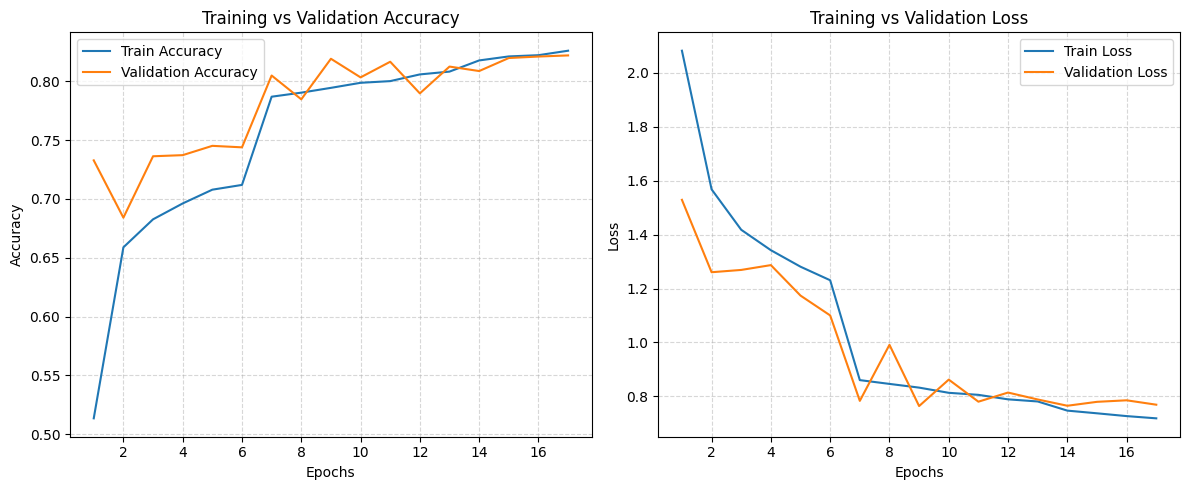

In [33]:
# Cell P — Plot Accuracy and Loss curves for both training stages
import matplotlib.pyplot as plt

# Merge histories if you have both (initial + fine-tune)
def combine_histories(histories):
    acc = []
    val_acc = []
    loss = []
    val_loss = []
    for h in histories:
        acc.extend(h.history.get('accuracy', []) or h.history.get('sparse_categorical_accuracy', []))
        val_acc.extend(h.history.get('val_accuracy', []) or h.history.get('val_sparse_categorical_accuracy', []))
        loss.extend(h.history.get('loss', []))
        val_loss.extend(h.history.get('val_loss', []))
    return acc, val_acc, loss, val_loss

# Combine training histories (initial + fine-tune)
try:
    acc, val_acc, loss, val_loss = combine_histories([history, history_ft])
except NameError:
    acc, val_acc, loss, val_loss = combine_histories([history])

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label='Train Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label='Train Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


In [34]:
# Cell Q — Compute and print average Precision, Recall, F1-score
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
import numpy as np

# Ensure you have y_true and y_pred from earlier test evaluation
# (If not, re-run the prediction cell first)

# Compute macro, micro, weighted averages
prec_macro = precision_score(y_true, y_pred, average='macro')
rec_macro  = recall_score(y_true, y_pred, average='macro')
f1_macro   = f1_score(y_true, y_pred, average='macro')

prec_micro = precision_score(y_true, y_pred, average='micro')
rec_micro  = recall_score(y_true, y_pred, average='micro')
f1_micro   = f1_score(y_true, y_pred, average='micro')

prec_weighted = precision_score(y_true, y_pred, average='weighted')
rec_weighted  = recall_score(y_true, y_pred, average='weighted')
f1_weighted   = f1_score(y_true, y_pred, average='weighted')

print("=== Average Precision / Recall / F1 ===")
print(f"Macro Precision : {prec_macro:.4f}")
print(f"Macro Recall    : {rec_macro:.4f}")
print(f"Macro F1-score  : {f1_macro:.4f}")
print()
print(f"Micro Precision : {prec_micro:.4f}")
print(f"Micro Recall    : {rec_micro:.4f}")
print(f"Micro F1-score  : {f1_micro:.4f}")
print()
print(f"Weighted Precision : {prec_weighted:.4f}")
print(f"Weighted Recall    : {rec_weighted:.4f}")
print(f"Weighted F1-score  : {f1_weighted:.4f}")

# Optionally print full per-class metrics
print("\n--- Per-class metrics ---")
print(classification_report(y_true, y_pred, digits=4))


=== Average Precision / Recall / F1 ===
Macro Precision : 0.5690
Macro Recall    : 0.4678
Macro F1-score  : 0.4897

Micro Precision : 0.8098
Micro Recall    : 0.8098
Micro F1-score  : 0.8098

Weighted Precision : 0.7596
Weighted Recall    : 0.8098
Weighted F1-score  : 0.7714

--- Per-class metrics ---
              precision    recall  f1-score   support

           0     0.8441    0.9752    0.9049      2581
           1     0.2500    0.0082    0.0158       245
           2     0.6491    0.4896    0.5582       529
           3     0.4412    0.3448    0.3871        87
           4     0.6607    0.5211    0.5827        71

    accuracy                         0.8098      3513
   macro avg     0.5690    0.4678    0.4897      3513
weighted avg     0.7596    0.8098    0.7714      3513

